# Naive - without enough experience of life and too ready to believe or trust other people

The "naive" in Naive Bayes comes from the algorithm's core assumption that all features (or attributes) are independent of each other. 
This means the presence or absence of one feature does not influence the presence or absence of another.




# Naive Bayes Classifier

Naive Bayes is a probabilistic classifier based on **Bayes’ Theorem**, assuming independence between features.

### Bayes' Theorem
Hmmmmm, you guys should know this !!

                  # P(class/data) = p(class) * p(data/class) / p(data)

P(class/data) ->  Probability that a data point belongs to a class, **given the data** (this is what you want to compute — **posterior**)

p(class) - > Prior belief about the class (before seeing the data) (**prior**)                                                               
p(data/class)   ->   How likely the data is assuming the class is true (**likelihood**)                                                      
p(data)   ->  Total probability of seeing the data across all classes (**evidence**)                                                


### "Naive" Assumption:
Assumes features are conditionally independent given the class



In [ ]:
 # a Simple way to remember 

Real-Life Example: Medical Diagnosis

Imagine:

    You’re testing for a rare disease.
    The disease affects 1 in 1,000 people.
    The test is 99% accurate:

        It detects 99% of people who have the disease (true positive).
        It falsely says 1% of healthy people have the disease (false positive).

In [ ]:
 The Question:
    If you test positive, what is the chance you actually have the disease?

# Even with a positive test, the probability you have the disease is only ~9%!

In [14]:
P_D = 0.001
P_ND = 0.999

P_pos_given_D = 0.99
P_neg_given_D = 1 - P_pos_given_D

P_pos_given_ND = 0.01
P_neg_given_ND = 1 - P_pos_given_ND

# Total probabilities using law of total probability
P_pos = P_pos_given_D * P_D + P_pos_given_ND * P_ND
P_neg = P_neg_given_D * P_D + P_neg_given_ND * P_ND

# Posterior probabilities using Bayes’ Theorem
P_D_given_pos = (P_pos_given_D * P_D) / P_pos
P_ND_given_pos = (P_pos_given_ND * P_ND) / P_pos

P_D_given_neg = (P_neg_given_D * P_D) / P_neg
P_ND_given_neg = (P_neg_given_ND * P_ND) / P_neg

# Print results
print("Posterior Probabilities:")
print(f"P(Disease | Positive) = {P_D_given_pos:.4f}")
print(f"P(No Disease | Positive) = {P_ND_given_pos:.4f}")
print(f"P(Disease | Negative) = {P_D_given_neg:.6f}")
print(f"P(No Disease | Negative) = {P_ND_given_neg:.6f}")



Posterior Probabilities:
P(Disease | Positive) = 0.0902
P(No Disease | Positive) = 0.9098
P(Disease | Negative) = 0.000010
P(No Disease | Negative) = 0.999990


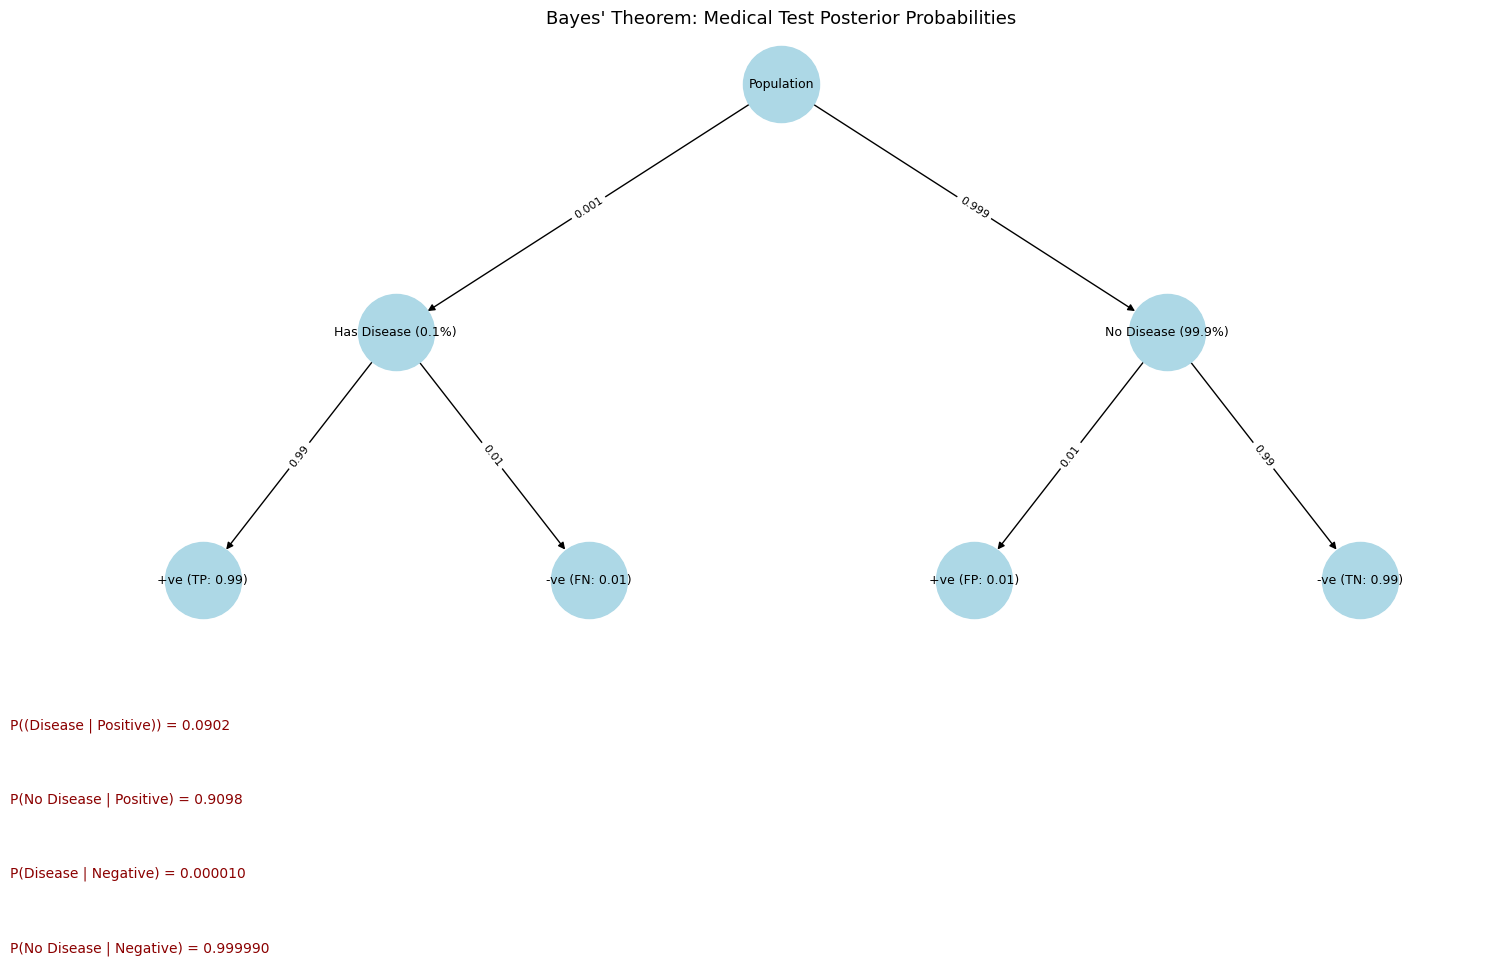

In [16]:
import matplotlib.pyplot as plt
import networkx as nx

# Bayes Computation (reuse from above)
P_D = 0.001
P_ND = 0.999
P_pos_given_D = 0.99
P_neg_given_D = 0.01
P_pos_given_ND = 0.01
P_neg_given_ND = 0.99
P_pos = P_pos_given_D * P_D + P_pos_given_ND * P_ND
P_neg = P_neg_given_D * P_D + P_neg_given_ND * P_ND

P_D_given_pos = (P_pos_given_D * P_D) / P_pos
P_ND_given_pos = (P_pos_given_ND * P_ND) / P_pos
P_D_given_neg = (P_neg_given_D * P_D) / P_neg
P_ND_given_neg = (P_neg_given_ND * P_ND) / P_neg

# Create graph
G = nx.DiGraph()
G.add_edges_from([
    ("Pop", "D"), ("Pop", "ND"),
    ("D", "D_Pos"), ("D", "D_Neg"),
    ("ND", "ND_Pos"), ("ND", "ND_Neg")
])

pos = {
    "Pop": (0, 1),
    "D": (-1, 0.5), "ND": (1, 0.5),
    "D_Pos": (-1.5, 0), "D_Neg": (-0.5, 0),
    "ND_Pos": (0.5, 0), "ND_Neg": (1.5, 0)
}

labels = {
    "Pop": "Population",
    "D": "Has Disease (0.1%)",
    "ND": "No Disease (99.9%)",
    "D_Pos": "+ve (TP: 0.99)",
    "D_Neg": "-ve (FN: 0.01)",
    "ND_Pos": "+ve (FP: 0.01)",
    "ND_Neg": "-ve (TN: 0.99)"
}

plt.figure(figsize=(14, 6))
nx.draw(G, pos, with_labels=False, node_color='lightblue', node_size=3000)
nx.draw_networkx_labels(G, pos, labels, font_size=9)

edge_labels = {
    ("Pop", "D"): "0.001",
    ("Pop", "ND"): "0.999",
    ("D", "D_Pos"): "0.99",
    ("D", "D_Neg"): "0.01",
    ("ND", "ND_Pos"): "0.01",
    ("ND", "ND_Neg"): "0.99"
}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

# Add posterior probabilities
posterior_text = [
    f"P((Disease | Positive)) = {P_D_given_pos:.4f}",
    f"P(No Disease | Positive) = {P_ND_given_pos:.4f}",
    f"P(Disease | Negative) = {P_D_given_neg:.6f}",
    f"P(No Disease | Negative) = {P_ND_given_neg:.6f}"
]
for i, text in enumerate(posterior_text):
    plt.text(-2, -0.3 - 0.15*i, text, fontsize=10, color='darkred')

plt.title("Bayes' Theorem: Medical Test Posterior Probabilities", fontsize=13)
plt.axis('off')
plt.show()


In [ ]:
# We'll classify whether a person will Buy a Computer (Yes or No) based on their Age and Income.

In [3]:
# Goal: Predict Buy = ? 
for a person with: Age = Young, Income = Medium Buy  = ?

In [4]:
import pandas as pd

# Dataset
data = pd.DataFrame({
    'Age': ['Young', 'Young', 'Middle', 'Senior', 'Senior', 'Senior', 'Middle',
            'Young', 'Young', 'Senior', 'Young', 'Middle', 'Middle', 'Senior'],
    'Income': ['High', 'High', 'High', 'Medium', 'Low', 'Low', 'Low',
               'Medium', 'Low', 'Medium', 'Medium', 'Medium', 'High', 'Medium'],
    'Buy': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
            'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
})

data.head()


,Age,Income,Buy
0,Young,High,No
1,Young,High,No
2,Middle,High,Yes
3,Senior,Medium,Yes
4,Senior,Low,Yes


In [8]:
# calculate priors
# Prior probabilities
P_yes = len(data[data['Buy'] == 'Yes']) / len(data)
P_no = len(data[data['Buy'] == 'No']) / len(data)

print(f"P(Yes) = {P_yes:.2f}")
print(f"P(No) = {P_no:.2f}")


P(Yes) = 0.64
P(No) = 0.36


In [9]:
# Likelihoods P(Age=Young∣Yes), P(Income=Medium | Yes), P(Age=Young | No) ,P(Income=Medium | No) 

# Likelihoods
def likelihood(feature, value, label):
    subset = data[data['Buy'] == label]
    return len(subset[subset[feature] == value]) / len(subset)

# For Buy = Yes
P_age_yes = likelihood('Age', 'Young', 'Yes')
P_income_yes = likelihood('Income', 'Medium', 'Yes')

# For Buy = No
P_age_no = likelihood('Age', 'Young', 'No')
P_income_no = likelihood('Income', 'Medium', 'No')

print(f"P(Age=Young | Yes) = {P_age_yes:.2f}")
print(f"P(Income=Medium | Yes) = {P_income_yes:.2f}")

print(f"P(Age=Young | No) = {P_age_no:.2f}")
print(f"P(Income=Medium | No) = {P_income_no:.2f}")


P(Age=Young | Yes) = 0.22
P(Income=Medium | Yes) = 0.44
P(Age=Young | No) = 0.60
P(Income=Medium | No) = 0.40


In [10]:
# Calculate Posterior (Unnormalized)

#    P(Yes∣X) = P(Yes)⋅P(Age=Young∣Yes)⋅P(Income=Medium∣Yes)

posterior_yes = P_yes * P_age_yes * P_income_yes
posterior_no = P_no * P_age_no * P_income_no

print(f"Posterior for YES: {posterior_yes:.4f}")
print(f"Posterior for NO : {posterior_no:.4f}")

# Final prediction
prediction = 'Yes' if posterior_yes > posterior_no else 'No'
print(f"\nFinal Prediction: {prediction}")


Posterior for YES: 0.0635
Posterior for NO : 0.0857

Final Prediction: No


In [17]:
# Actual Posterior posteriors
total = posterior_yes + posterior_no

P_yes_given_X = posterior_yes / total
P_no_given_X = posterior_no / total

print(f"Normalized P(Yes | X): {P_yes_given_X:.4f}")
print(f"Normalized P(No  | X): {P_no_given_X:.4f}")

prediction = 'Yes' if posterior_yes > posterior_no else 'No'
print(f"\nFinal Prediction: {prediction}")


Normalized P(Yes | X): 0.4255
Normalized P(No  | X): 0.5745

Final Prediction: No


# Types

In [18]:
# Spam Email Classification (Text Data)

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Load sample dataset: 2 categories - sci.space and rec.autos as proxy for ham/spam
categories = ['sci.space', 'rec.autos']
data = fetch_20newsgroups(subset='train', categories=categories)

# Convert text to counts (Bag of Words)
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(data.data)
y = data.target

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Train Multinomial Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)

# Predict & Evaluate
y_pred = nb.predict(X_test)
print(classification_report(y_test, y_pred, target_names=categories))


              precision    recall  f1-score   support

   sci.space       0.99      0.99      0.99       135
   rec.autos       0.99      0.99      0.99       162

    accuracy                           0.99       297
   macro avg       0.99      0.99      0.99       297
weighted avg       0.99      0.99      0.99       297



In [23]:
# Iris Flower Classification (Continuous Data)
from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load data
iris = load_iris()
X, y = iris.data, iris.target

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Train Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predict & Evaluate
y_pred = gnb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 1.0


In [20]:
# Sentiment Analysis on Movie Reviews (Text Data)
from sklearn.datasets import load_files
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Download movie review dataset from sklearn or load your own (you may need to download external dataset)
# Here we simulate with 20newsgroups 

# Example assuming you have positive and negative folders in 'movie_reviews' dir:
# data = load_files('movie_reviews/', categories=['pos', 'neg'])

# For demonstration, use 20newsgroups subset as proxy again
categories = ['rec.autos', 'rec.sport.hockey']
data = fetch_20newsgroups(subset='train', categories=categories)

# TF-IDF Vectorizer for text
tfidf = TfidfVectorizer(stop_words='english')
X = tfidf.fit_transform(data.data)
y = data.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Train Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)

# Predict & Evaluate
y_pred = nb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9866220735785953


In [21]:
# Disease Prediction (Categorical Features)
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Sample data
data = pd.DataFrame({
    'Fever': ['Yes', 'No', 'Yes', 'Yes', 'No', 'No', 'Yes', 'No'],
    'Cough': ['Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No'],
    'Disease': ['Flu', 'No', 'Flu', 'Flu', 'Cold', 'No', 'Flu', 'No']
})

# Encode categorical features
le_fever = LabelEncoder()
le_cough = LabelEncoder()
le_disease = LabelEncoder()

X = pd.DataFrame({
    'Fever': le_fever.fit_transform(data['Fever']),
    'Cough': le_cough.fit_transform(data['Cough'])
})
y = le_disease.fit_transform(data['Disease'])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Train Categorical Naive Bayes (available from sklearn 0.22+)
cnb = CategoricalNB()
cnb.fit(X_train, y_train)

# Predict & Evaluate
y_pred = cnb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 1.0


In [1]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Sample dataset
texts = [
    "Free money now!!!", 
    "Hi, how are you?", 
    "Win cash instantly", 
    "Let's catch up tomorrow", 
    "Get free access", 
    "Lunch meeting at 1 PM"
]
labels = [1, 0, 1, 0, 1, 0]  # 1 = Spam, 0 = Ham (not spam)

# Convert text to binary features (word presence/absence)
vectorizer = CountVectorizer(binary=True)
X = vectorizer.fit_transform(texts)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.3, random_state=42)

# Train Bernoulli Naive Bayes model
model = BernoulliNB()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# Show prediction on new text
new_texts = ["Free offer", "Can we talk later?"]
new_features = vectorizer.transform(new_texts)
print("Predictions:", model.predict(new_features))  


Accuracy: 0.5
Predictions: [1 1]
